# M12 · Two-Tower / EBR Retrieval — Hands-on, Step by Tiny Step

**Companion to lesson M12. Written for someone new to ML.**

When a request has to search **millions** of candidates (creators, ads, docs), you can't score
them all with a heavy model per request. The standard first-stage trick is a **two-tower
model**: one tower turns the **query** into a vector, another turns each **item** into a
vector, and a match is just a **dot product** in a shared space. Because item vectors don't
depend on the live query, you **precompute** them once and, at serving time, only run the
query tower + a fast **vector search**.

**What you'll do (every step has an explanation, logging, and a picture):**
- **Part A · The model & training:** build **two towers** (PyTorch), train them with the
  **in-batch softmax** loss, measure **recall@k**, see how **hard negatives** sharpen the
  model, and apply the **logQ** correction.
- **Part B · Serving:** **precompute** item vectors, build an **ANN index** (IVF-style),
  **sweep the funnel** (recall vs latency) to an operating point, and hit the **freshness**
  trap.

We use **PyTorch** (for the towers) + **scikit-learn** + **matplotlib** — all preinstalled in
Colab. Run each cell with **Shift+Enter**.

## Step 1 · Setup

In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn
torch.manual_seed(0)
plt.rcParams.update({"axes.grid": True, "grid.alpha": .3, "figure.autolayout": True})
BLUE, GREEN, RED, PURPLE, GOLD, GRAY = "#4C72B0", "#55A868", "#C44E52", "#8172B3", "#CCB974", "#888"
print("ready")

ready


---
# Part A · The two-tower model & training

## Step 2 · What is a two-tower model?

Two separate encoders ("towers"):
- **query tower** `f_q(q)` → a vector for the request (a search query, an advertiser brief),
- **item tower** `f_i(i)` → a vector for each candidate (a creator, an ad).

Both output into the **same space**, and the match score is a **dot product**:
$$s(q,i)=f_q(q)^\top f_i(i)$$
The magic: item vectors **don't depend on the live query**, so you compute them **offline**,
index them, and at request time only run the query tower + a vector search. (A *cross-encoder*
that reads `(query, item)` together is more accurate but must run once per pair — too slow for
millions. That's why two-tower is the **first stage**.)

## Step 3 · The training loss — in-batch softmax

In a batch of `B` matched `(query, item)` pairs, score **every query against every item in the
batch**. For each query, its own item is the **positive**; the other `B−1` items are
**negatives**. The loss makes the positive win a softmax:
$$\mathcal{L}_b=-\log\frac{e^{s(q_b,i_b)}}{\sum_{j=1}^{B} e^{s(q_b,i_j)}}$$
Worked example from the lesson: one query scored against 3 items — positive **4.0**, easy
negative **1.0**, hard negative **3.8**. The hard negative (close to the positive) keeps the
loss high — that's the pressure that teaches fine distinctions.

positive probability: 0.54  loss: 0.63
if hard neg were easy: positive prob 0.93  loss 0.08 (tiny)


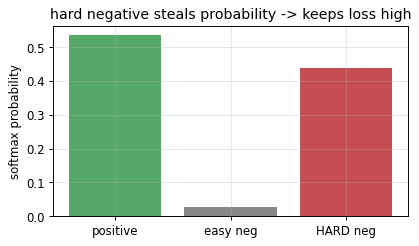

In [6]:
scores = np.array([4.0, 1.0, 3.8])            # [positive, easy neg, hard neg]
probs = np.exp(scores) / np.exp(scores).sum()
print("positive probability:", round(probs[0], 2), " loss:", round(-np.log(probs[0]), 2))

# if the hard negative were easy (0.5 instead of 3.8):
easy = np.array([4.0, 1.0, 0.5]); pe = np.exp(easy)/np.exp(easy).sum()
print("if hard neg were easy: positive prob", round(pe[0],2), " loss", round(-np.log(pe[0]),2), "(tiny)")
plt.figure(figsize=(5,3)); plt.bar(["positive","easy neg","HARD neg"], np.exp(scores)/np.exp(scores).sum(), color=[GREEN,GRAY,RED])
plt.ylabel("softmax probability"); plt.title("hard negative steals probability -> keeps loss high"); plt.show()

## Step 4 · Build & train the two towers (PyTorch)

We make synthetic data: queries and their matched items share a hidden "topic + taste," so a
positive pair should score high. Each tower is a small network mapping **raw features →
embedding**. We train with the in-batch softmax: in code that's just a **cross-entropy where
the correct class is the diagonal** of the query×item score matrix.

  epoch  0: in-batch softmax loss 4.099
  epoch  3: in-batch softmax loss 2.030
  epoch  6: in-batch softmax loss 1.391
  epoch  9: in-batch softmax loss 1.146
  epoch 12: in-batch softmax loss 0.982


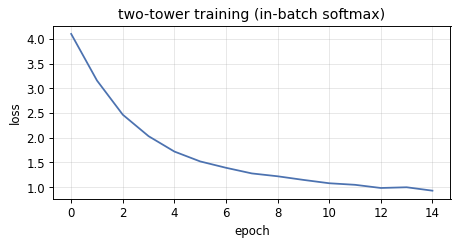

In [8]:
D_raw, D_emb, V = 32, 16, 8
rng = np.random.default_rng(0)
centers = rng.normal(0, 1, (V, D_raw))                    # a topic center per vertical
def make(n, seed):
    r = np.random.default_rng(seed); v = r.integers(0, V, n)
    taste = r.normal(0, 1, (n, D_raw)) * 0.5
    q = centers[v] + taste + r.normal(0, 0.3, (n, D_raw))
    i = centers[v] + taste + r.normal(0, 0.3, (n, D_raw))  # matched item shares topic+taste
    return torch.tensor(q, dtype=torch.float32), torch.tensor(i, dtype=torch.float32)
Q, I = make(4000, 1)
Qte, Ite = make(1000, 2)

class Tower(nn.Module):
    def __init__(self):
        super().__init__(); self.net = nn.Sequential(nn.Linear(D_raw, 32), nn.ReLU(), nn.Linear(32, D_emb))
    def forward(self, x): return self.net(x)

query_tower, item_tower = Tower(), Tower()
opt = torch.optim.Adam(list(query_tower.parameters()) + list(item_tower.parameters()), lr=0.01)

def in_batch_loss(qe, ie):
    S = qe @ ie.T                          # [B,B] every query vs every item in the batch
    labels = torch.arange(len(qe))         # the positive for row b is item b (the diagonal)
    return nn.functional.cross_entropy(S, labels)

B = 256; losses = []
for epoch in range(15):
    perm = torch.randperm(len(Q)); tot = 0.0; nb = 0
    for k in range(0, len(Q), B):
        idx = perm[k:k+B]
        loss = in_batch_loss(query_tower(Q[idx]), item_tower(I[idx]))
        opt.zero_grad(); loss.backward(); opt.step(); tot += loss.item(); nb += 1
    losses.append(tot/nb)
    if epoch % 3 == 0: print(f"  epoch {epoch:>2}: in-batch softmax loss {losses[-1]:.3f}")
plt.figure(figsize=(5.5,3)); plt.plot(losses, color=BLUE)
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("two-tower training (in-batch softmax)"); plt.show()

## Step 5 · Evaluate — recall@k

Retrieval quality: embed the test queries and items, score each query against **all** test
items, and ask **"is the true match in the top k?"** That's recall@k.

recall@ 1: 0.375   (random 0.001)
recall@ 5: 0.712   (random 0.005)
recall@10: 0.833   (random 0.010)
recall@20: 0.940   (random 0.020)


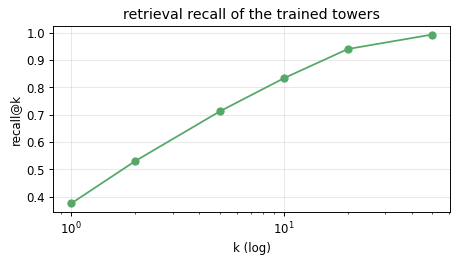

In [10]:
with torch.no_grad():
    qe, ie = query_tower(Qte), item_tower(Ite)
    S = (qe @ ie.T).numpy()                # row r's positive item is item r
def recall_at_k(S, k):
    return np.mean([r in np.argpartition(-S[r], k)[:k] for r in range(len(S))])
for k in [1, 5, 10, 20]:
    print(f"recall@{k:>2}: {recall_at_k(S,k):.3f}   (random {k/len(S):.3f})")
ks = [1,2,5,10,20,50]; rec = [recall_at_k(S,k) for k in ks]
plt.figure(figsize=(5.5,3.2)); plt.plot(ks, rec, "o-", color=GREEN)
plt.xscale("log"); plt.xlabel("k (log)"); plt.ylabel("recall@k"); plt.title("retrieval recall of the trained towers"); plt.show()

## Step 6 · Negative types — and why **hard negatives** matter

Where do the negatives come from? Four choices:
- **random** — a random item from the corpus (clearly wrong; teaches broad separation).
- **in-batch** — the other positives in the batch (cheap — what we used above).
- **sampled** — drawn from a distribution (needs logQ correction — next step).
- **hard** — plausible-but-wrong items (force the sharpest boundary).

A **hard negative** competes with the positive in the softmax, so it **steals probability** and
keeps the gradient alive. Lesson example: positive 3.0, easy 0.2, hard 2.8.

positive probability WITH a hard negative : 0.53 -> loss 0.63
positive probability WITHOUT it           : 0.94 -> loss 0.06
the gap is the training signal: a hard negative forces the model to separate look-alikes.

caution: a hard negative must actually be NEGATIVE. two valid creators for one brief
can look like a hard pair -> filter false negatives before training.


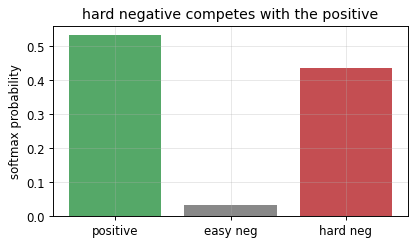

In [12]:
def softmax(x): x = x - x.max(); return np.exp(x)/np.exp(x).sum()
with_hard    = softmax(np.array([3.0, 0.2, 2.8]))   # positive, easy, HARD
without_hard = softmax(np.array([3.0, 0.2]))         # positive, easy only
print("positive probability WITH a hard negative :", round(with_hard[0], 2), "-> loss", round(-np.log(with_hard[0]),2))
print("positive probability WITHOUT it           :", round(without_hard[0], 2), "-> loss", round(-np.log(without_hard[0]),2))
print("the gap is the training signal: a hard negative forces the model to separate look-alikes.")
plt.figure(figsize=(5,3))
plt.bar(["positive","easy neg","hard neg"], with_hard, color=[GREEN, GRAY, RED])
plt.ylabel("softmax probability"); plt.title("hard negative competes with the positive"); plt.show()
print("\ncaution: a hard negative must actually be NEGATIVE. two valid creators for one brief")
print("can look like a hard pair -> filter false negatives before training.")

## Step 7 · logQ — correcting the negative sampler

If you **sample** negatives (e.g. by popularity), popular items appear too often *just because
the sampler favors them* — the model would learn the sampler, not the task. Subtract the log
sampling probability from the score before the softmax:
$$s'(q,i)=s(q,i)-\log Q(i)$$
(Same correction you saw in M10/M11.) Lesson example: raw score 2.0 for two negatives sampled
with `Q=0.20` (popular) and `Q=0.01` (rare).

In [14]:
for Q in [0.20, 0.01]:
    print(f"raw score 2.0, sampled with Q={Q:<4} -> corrected {2.0 - np.log(Q):.2f}")
print("the rare item (small Q) is lifted more: each rare draw represents many un-sampled peers.")

raw score 2.0, sampled with Q=0.2  -> corrected 3.61
raw score 2.0, sampled with Q=0.01 -> corrected 6.61
the rare item (small Q) is lifted more: each rare draw represents many un-sampled peers.


---
# Part B · Serving two-tower retrieval

## Step 8 · The serving funnel — precompute, then search

Serving works because item vectors **don't depend on the live query**:

```
OFFLINE:  item tower -> item vectors -> build ANN index (versioned)
ONLINE :  request -> query tower -> ONE query vector -> ANN top-K
          -> filters/dedupe -> hand top-K to the ranker
```

No negatives are sampled online — the index just returns the highest-scoring candidates. Let's
precompute our item vectors and serve a query with **exact** (brute-force) search first.

In [17]:
with torch.no_grad():
    item_vecs  = item_tower(Ite).numpy()        # PRECOMPUTED offline, indexed once
    query_vecs = query_tower(Qte).numpy()       # computed per request online

def exact_topk(qv, k=50): return set(np.argsort(-(item_vecs @ qv))[:k])
example = exact_topk(query_vecs[0], 10)
print("exact brute-force top-10 for query 0:", sorted(example))
print("true match (item 0) retrieved?", 0 in example)
print("\nbrute force scores ALL", len(item_vecs), "items per query -> correct but slow at scale.")

exact brute-force top-10 for query 0: [0, 74, 200, 314, 338, 346, 568, 637, 895, 996]
true match (item 0) retrieved? True

brute force scores ALL 1000 items per query -> correct but slow at scale.


## Step 9 · An ANN index — scan a fraction, keep most of the recall

Brute force is too slow at millions of items. An **ANN index** scans only a **fraction**. We
build a simple **IVF-style** index: cluster items into cells; at query time probe only the
nearest `nprobe` cells. Sweeping `nprobe` trades **recall** for **work scanned** — the core
retrieval knob (M13 goes deeper on HNSW / IVF-PQ / ScaNN).

In [19]:
from sklearn.cluster import KMeans
nlist = 64
km = KMeans(nlist, n_init=3, random_state=0).fit(item_vecs)
cents = km.cluster_centers_
members = [np.where(km.labels_ == c)[0] for c in range(nlist)]

def ivf_topk(qv, nprobe, k=50):
    near = np.argsort(-(cents @ qv))[:nprobe]                       # nearest cells
    cand = np.concatenate([members[c] for c in near])
    if len(cand) < k: return set(cand)
    return set(cand[np.argsort(-(item_vecs[cand] @ qv))[:k]])

print(f"IVF index: {len(item_vecs)} items in {nlist} cells\n")
print(f"{'nprobe':>7}{'recall@50':>11}{'% scanned':>11}")
rows = []
for nprobe in [1, 2, 4, 8, 16, 32]:
    recs, scan = [], []
    for qv in query_vecs:
        ex = exact_topk(qv, 50); ap = ivf_topk(qv, nprobe, 50)
        recs.append(len(ex & ap)/50)
        scan.append(sum(len(members[c]) for c in np.argsort(-(cents@qv))[:nprobe])/len(item_vecs))
    rows.append((nprobe, np.mean(recs), np.mean(scan)))
    print(f"{nprobe:>7}{np.mean(recs):>11.2f}{np.mean(scan)*100:>10.1f}%")

IVF index: 1000 items in 64 cells

 nprobe  recall@50  % scanned
      1       0.26       1.7%
      2       0.46       3.4%
      4       0.74       6.7%
      8       0.96      12.8%
     16       1.00      24.5%
     32       1.00      49.5%


## Step 10 · Read the tradeoff — pick an operating point

Plot **recall vs work scanned** (a proxy for latency). Every extra bit of recall costs more
scanning. You pick the **cheapest point that meets the product's recall bar** — not the max.

cheapest setting meeting recall>=0.95: nprobe=8 (0.96 recall, 12.8% scanned)


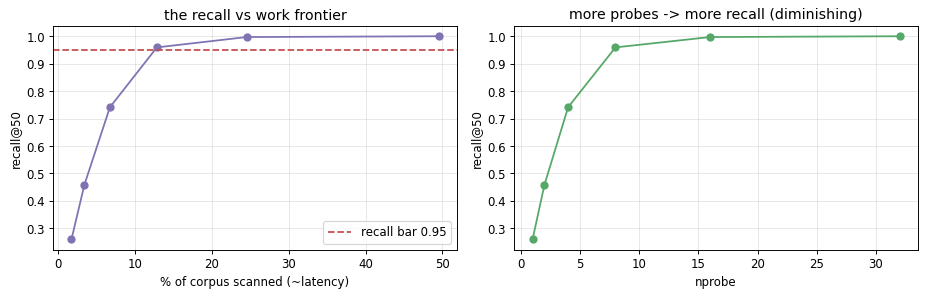

In [21]:
nprobes = [r[0] for r in rows]; recs = [r[1] for r in rows]; scans = [r[2]*100 for r in rows]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(scans, recs, "o-", color=PURPLE)
for np_, s, rc in rows: ax[0].annotate(f"nprobe={np_}", (s*100, rc), textcoords="offset points", xytext=(5,-8), fontsize=8)
ax[0].axhline(0.95, color=RED, ls="--", label="recall bar 0.95")
ax[0].set_xlabel("% of corpus scanned (~latency)"); ax[0].set_ylabel("recall@50"); ax[0].legend()
ax[0].set_title("the recall vs work frontier")
ax[1].plot(nprobes, recs, "o-", color=GREEN); ax[1].set_xlabel("nprobe"); ax[1].set_ylabel("recall@50")
ax[1].set_title("more probes -> more recall (diminishing)")
plt.show()
ok = [r for r in rows if r[1] >= 0.95]
if ok:
    best = min(ok, key=lambda r: r[2])
    print(f"cheapest setting meeting recall>=0.95: nprobe={best[0]} ({best[1]:.2f} recall, {best[2]*100:.1f}% scanned)")

## Step 11 · The freshness trap — stale embeddings

Item vectors are precomputed on a schedule. If a creator **changes** (e.g. rebrands to "B2B
cybersecurity") but the index still holds **yesterday's** vector, searches miss them until the
next rebuild. **ANN recall against the stale index can look fine while product recall for fresh
items is poor.** Freshness is a *serving* metric, not a modeling afterthought.

recall@50 for rebranded creators:
  against STALE index (old vectors): 0.49  <- they vanish
  against FRESH index (new vectors): 0.99  <- rebuild fixes it


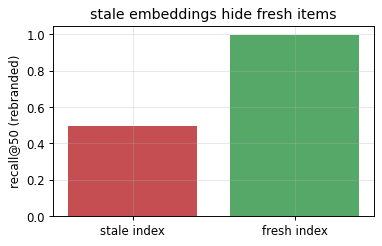

In [23]:
# a creator rebrands: their TRUE vector moves, but the index still has the old one
rng = np.random.default_rng(3)
changed = rng.choice(len(item_vecs), 200, replace=False)
new_true = item_vecs.copy()
new_true[changed] += rng.normal(0, 2.5, (200, item_vecs.shape[1]))   # big profile change

# queries that now match the NEW profile
q_new = new_true[changed] + rng.normal(0, 0.2, (200, item_vecs.shape[1]))
def found(index_vecs):
    hits = 0
    for j, qv in zip(changed, q_new):
        if j in set(np.argsort(-(index_vecs @ qv))[:50]): hits += 1
    return hits/len(changed)
print("recall@50 for rebranded creators:")
print(f"  against STALE index (old vectors): {found(item_vecs):.2f}  <- they vanish")
print(f"  against FRESH index (new vectors): {found(new_true):.2f}  <- rebuild fixes it")
plt.figure(figsize=(4.6,3)); plt.bar(["stale index","fresh index"], [found(item_vecs), found(new_true)], color=[RED, GREEN])
plt.ylabel("recall@50 (rebranded)"); plt.title("stale embeddings hide fresh items"); plt.show()

---
## Recap — the M12 toolkit

**The model (Part A).** A **two-tower** model encodes the **query** and each **item**
separately into a shared space; the score is a **dot product**. You train it with the
**in-batch softmax** loss (each query's own item is the positive, the rest of the batch are
negatives). **Hard negatives** — plausible-but-wrong items — compete with the positive in the
softmax and force sharper boundaries (but must be truly negative). When you **sample**
negatives, apply the **logQ** correction so the model learns the task, not the sampler.

**Serving (Part B).** Because item vectors don't depend on the query, you **precompute** and
**index** them; online you run only the **query tower** + a fast **ANN** search. The **ANN knob**
(here `nprobe`) trades **recall for work/latency** — pick the **cheapest point that meets the
recall bar**. Watch **freshness**: a stale index hides items that recently changed.

**Where this connects:** M12 turns M11's embeddings into a retrieval *system*. Its in-batch
softmax + negatives build on M10 (sampling, logQ). The ANN index is the subject of **M13**
(HNSW / IVF-PQ / ScaNN tuning), and the towers themselves are **encoders** trained
contrastively — the subject of **M14**.